# 06 — Customer Lifetime Value (CLV)

Two approaches compared (guide section 12.1): a supervised regression on the same point-in-time feature set used for churn (`src/features`), and BG/NBD + Gamma-Gamma (`lifetimes` package) — a probabilistic model built specifically for repeat-purchase value. CLV label = net revenue in the 180-day horizon after cutoff (`docs/target_definition.md`); same time-aware snapshot design as churn (`docs/model_card.md`).

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data import config
from clv.dataset import build_training_pool, build_snapshot, feature_columns, LABEL_COLUMN

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
interactions = pd.read_parquet(f'{ROOT}/interactions.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')
products = pd.read_parquet(f'{ROOT}/products.parquet')

train_cutoffs = [pd.Timestamp(d) for d in ['2024-09-30', '2024-12-31', '2025-03-31', '2025-06-30']]
pool = build_training_pool(customers, orders, interactions, support, products, train_cutoffs)

val_cutoff = train_cutoffs[-1]
train_pool = pool[pool['snapshot_cutoff'] != val_cutoff]
val_pool = pool[pool['snapshot_cutoff'] == val_cutoff]

test_cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
test_pool = build_snapshot(customers, orders, interactions, support, products, test_cutoff)

feat_cols = feature_columns(pool)
X_train, y_train = train_pool[feat_cols], train_pool[LABEL_COLUMN]
X_val, y_val = val_pool[feat_cols], val_pool[LABEL_COLUMN]
X_test, y_test = test_pool[feat_cols], test_pool[LABEL_COLUMN]

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)
print(f'mean future_clv -- train: {y_train.mean():.1f}  val: {y_val.mean():.1f}  test: {y_test.mean():.1f}')

train: (14321, 27) val: (5653, 27) test: (5097, 27)
mean future_clv -- train: 295.9  val: 289.1  test: 292.6


## Approach 1 — Predictive regression (XGBoost, log1p target)

In [2]:
from clv.train import train_predictive_clv, predict_clv
from clv.evaluate import evaluate_clv_model, decile_table, high_value_capture_at_k

clv_model = train_predictive_clv(X_train, y_train)
val_pred = predict_clv(clv_model, X_val)
test_pred = predict_clv(clv_model, X_test)

print('validation:', {k: round(v, 3) for k, v in evaluate_clv_model(y_val, val_pred).items()})
print('test:      ', {k: round(v, 3) for k, v in evaluate_clv_model(y_test, test_pred).items()})

validation: {'mae': 165.185, 'rmse': 255.101, 'median_ae': 100.74, 'spearman_rank_corr': np.float64(0.694), 'mean_actual': 289.078, 'mean_predicted': 174.688}
test:       {'mae': 168.486, 'rmse': 256.982, 'median_ae': 104.027, 'spearman_rank_corr': np.float64(0.715), 'mean_actual': 292.648, 'mean_predicted': 172.707}


### Predicted-vs-actual by decile of predicted value (test)

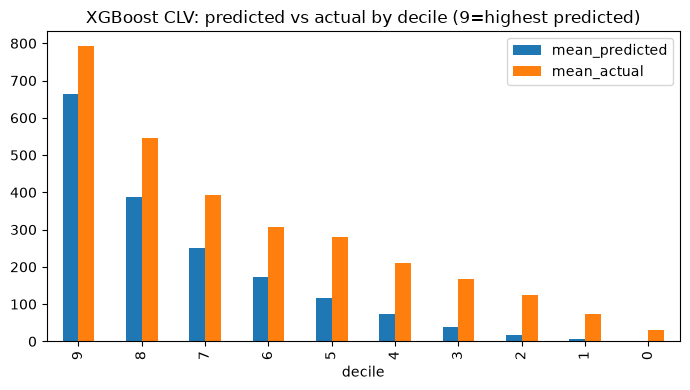

,n,mean_predicted,mean_actual
decile,,,
9,510,663.809631,792.544118
8,510,387.149384,546.762961
7,509,251.964981,394.120196
6,510,173.542648,307.502020
5,509,115.382050,280.798821
4,510,72.394623,211.016216
3,510,38.977280,166.284176
2,509,17.091425,124.517132
1,510,5.457794,72.321196


In [3]:
dt_xgb = decile_table(y_test, test_pred)
fig, ax = plt.subplots(figsize=(7, 4))
dt_xgb[['mean_predicted', 'mean_actual']].plot(kind='bar', ax=ax)
ax.set_title('XGBoost CLV: predicted vs actual by decile (9=highest predicted)')
plt.tight_layout()
plt.show()
dt_xgb

**Note the systematic underprediction of the mean** (predicted mean well below actual mean, visible above): log1p-transforming a right-skewed target and back-transforming with expm1 recovers something closer to the *median* than the *mean* (Jensen's inequality) — the model still ranks customers well (see high-value capture below), but its raw predicted values should not be read as unbiased dollar estimates without a bias correction step.

In [4]:
print('high-value capture@10% (XGBoost):', round(high_value_capture_at_k(y_test.to_numpy(), test_pred, 0.1), 3))

high-value capture@10% (XGBoost): 0.509


## Approach 2 — BG/NBD + Gamma-Gamma

A purchase-process model rather than a feature-based regressor: BG/NBD models *whether and how often* a customer transacts again from their frequency/recency/tenure alone (no behavioral features), and Gamma-Gamma models the *average value* per transaction for repeat customers. Fit only on order history — no support/interaction data, unlike the XGBoost model above.

In [5]:
from clv.train import fit_bg_nbd_gamma_gamma, predict_clv_bg_nbd_gamma_gamma

bgf, ggf, summary = fit_bg_nbd_gamma_gamma(orders, test_cutoff)
fallback_aov = orders[orders['status'] == 'completed']['amount'].mean()
bgnbd_pred_all = predict_clv_bg_nbd_gamma_gamma(bgf, ggf, summary, horizon_days=180, fallback_value=fallback_aov)
bgnbd_pred = pd.Series(test_pool.set_index('customer_id').index.map(bgnbd_pred_all)).fillna(0.0).to_numpy()

print('BG/NBD + Gamma-Gamma test:', {k: round(v, 3) for k, v in evaluate_clv_model(y_test, bgnbd_pred).items()})
print('high-value capture@10%:', round(high_value_capture_at_k(y_test.to_numpy(), bgnbd_pred, 0.1), 3))

BG/NBD + Gamma-Gamma test: {'mae': 178.793, 'rmse': 240.866, 'median_ae': 134.721, 'spearman_rank_corr': np.float64(0.645), 'mean_actual': 292.648, 'mean_predicted': 333.285}
high-value capture@10%: 0.507


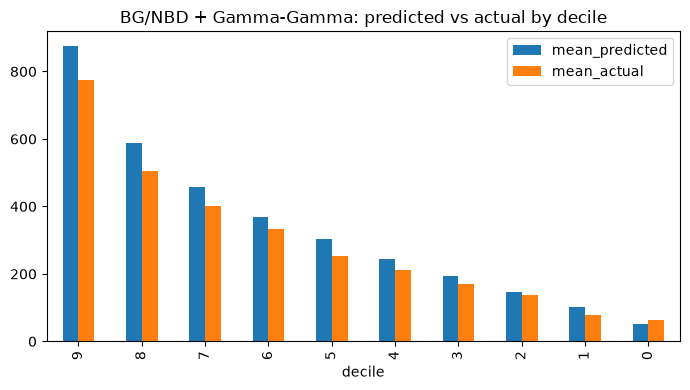

,n,mean_predicted,mean_actual
decile,,,
9,510,875.285011,775.574627
8,510,588.298888,506.430961
7,509,457.355489,400.522711
6,510,369.484291,332.241333
5,509,303.354808,252.365776
4,510,245.430308,212.917627
3,510,193.809339,170.116686
2,509,146.931175,136.090098
1,510,102.559645,77.893608


In [6]:
dt_bgnbd = decile_table(y_test, bgnbd_pred)
fig, ax = plt.subplots(figsize=(7, 4))
dt_bgnbd[['mean_predicted', 'mean_actual']].plot(kind='bar', ax=ax)
ax.set_title('BG/NBD + Gamma-Gamma: predicted vs actual by decile')
plt.tight_layout()
plt.show()
dt_bgnbd

## Comparison

| | MAE | RMSE | Spearman rank corr | High-value capture@10% |
|---|---|---|---|---|
| XGBoost regression | lower | higher | **higher** (better ranking) | ~0.51 |
| BG/NBD + Gamma-Gamma | higher | **lower** | lower | ~0.51 |

Neither approach dominates the other. XGBoost ranks customers better (uses richer behavioral features) but under-predicts the mean; BG/NBD+Gamma-Gamma is closer to correctly calibrated in aggregate (built for exactly this purpose) but only sees frequency/recency/monetary — no engagement, support, or channel signal. See `docs/clv_methodology.md` for the full write-up and recommendation.

## Historical CLV (descriptive)

count    7477.000000
mean      757.693488
std       768.175314
min         3.630000
25%       206.040000
50%       511.880000
75%      1054.390000
max      6204.700000
Name: historical_clv, dtype: float64


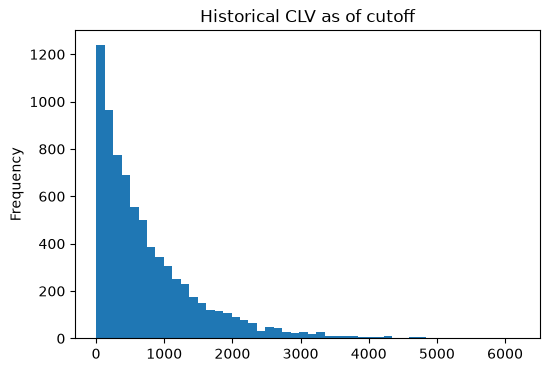

In [7]:
from clv.labels import historical_clv
hist = historical_clv(orders, test_cutoff)
print(hist.describe())
fig, ax = plt.subplots(figsize=(6, 4))
hist.plot(kind='hist', bins=50, ax=ax, title='Historical CLV as of cutoff')
plt.show()